# March-Madness -- does the NCAA tournament distract the market lower?
### A three-week sports distraction, tested honestly, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Busted%3F: Yes](https://img.shields.io/badge/Busted%3F-Yes-8b949e?style=flat-square)

Every March, the same headline returns: the NCAA basketball tournament costs American employers *billions* in lost productivity while half the office streams buzzer-beaters at their desks. The natural Wall-Street corollary writes itself -- if the whole country is distracted for three weeks, the stock market must drift, sag, or get choppy. This notebook asks the only question that matters: does the S&P 500 actually behave differently during the bracket, or is March Madness just March?

> **This is the plain-language layer.** Want the HAC t-stat, the variance test, and the permutation null? That's **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from march_madness import data, strategy as st

def _have_real():
    try:
        data.fetch_daily()   # cache-only (fetch=False)
        return True
    except (FileNotFoundError, RuntimeError):
        return False

HAVE_REAL = _have_real()
print("Real ^GSPC cache present:", HAVE_REAL)

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-17)
R = dict(
    n=10330, years=41.0, fp="2d2855ee9407",
    n_in=503, frac_in_pct=4.9,
    in_mean_bps=4.65, out_mean_bps=4.23, diff_bps=0.42,
    in_hac_t=1.01, out_hac_t=4.16, welch_t=0.086,
    in_vol_pct=16.8, out_vol_pct=18.2, vol_ratio=0.849, levene_p=0.295,
    perm_pct=52.9,
    bah_cagr_pct=9.48, strat_gross_cagr_pct=9.52, strat_net_cagr_pct=9.50,
    excess_net_pp=0.02, excess_net_t=-0.101, n_switches=80,
    sub1_diff_bps=-3.93, sub1_t=-0.61, sub2_diff_bps=4.79, sub2_t=0.66,
    year_start=1985, year_end=2025,
)


Real ^GSPC cache present: True


## The answer first

| Question | Answer |
|---|---|
| Are returns lower during the tournament? | **No.** In-window days earn **+4.65 bps/day** -- *above* the +4.23 bps the rest of the year earns. The gap is +0.42 bps, the wrong sign for the folklore, with t = 0.09. |
| Is the market more chaotic (volatile)? | **No.** In-window volatility is **16.8%** vs 18.2% outside -- a ratio of 0.85. The bracket window is *calmer*. |
| Are these particular days special at all? | **No.** A random 5% of days beats the tournament mean **53%** of the time -- it sits at the median of pure chance. |
| Could you trade it? | **No.** 'Hold cash during the bracket' ties buy-and-hold (+0.02pp/yr) and you pay commissions for the privilege. |

> March Madness distracts office workers, not the people who set S&P 500 futures prices. There is no market in the madness.

## 1 - The claim

> *"During the three weeks of March Madness, America stops working and starts watching basketball. Volume thins, attention wanders, and the market drifts lower -- a distraction you can see in the tape."*

The cultural anchor is the annual Challenger, Gray & Christmas press release estimating billions in lost workplace productivity each March. It's catnip for a market-folklore take. But lost desk-hours are not the same as a mispriced index -- and that gap is exactly what we test.

## 2 - So what?

If a sports tournament reliably pushed the S&P down for three weeks, it would be a free calendar trade: short in mid-March, cover in early April, every year. Markets would be very strange indeed if a basketball bracket -- known years in advance, on the calendar for everyone -- left a persistent, harvestable footprint.

## 3 - How would we even know?

Three traps to avoid:

1. **The direction.** The claim is *lower* returns. We must check the sign, not just the magnitude -- and report it honestly even when it points the wrong way.
2. **Tiny window.** Each tournament is ~3 weeks; over 40 brackets (2020 was cancelled) that's only ~500 trading days -- about 5% of the tape. With ~1%/day noise, the standard error on the in-window mean is ~0.5 bps, so only a big drag would ever be visible.
3. **Is it special?** Any random 5% of days will look a little high or a little low. The right question is whether *these* days are unusual versus a random window of the same size.

We test on ^GSPC daily price returns, 1985-2025 (the 64-team bracket era), with the tournament windows hardcoded in `data.py`.

## 4 - The teardown -- let's actually look

**First, meet the windows:** every tournament's first-round Thursday through championship Monday, hardcoded, and the share of trading days they cover.

In [2]:
tbl = data.tournament_table()
print('Brackets covered:', len(tbl), '(1985-2025; 2020 cancelled)')
if HAVE_REAL:
    ret, mask = data.fetch_daily()
    n_in = int(mask.sum()); n_tot = len(ret); frac = mask.mean()
else:
    n_in, n_tot, frac = R['n_in'], R['n'], R['frac_in_pct']/100
print(f'In-tournament trading days: {n_in} / {n_tot} = {frac:.1%} of the tape')
print()
print(tbl.head(3).to_string(index=False))
print('...')
print(tbl.tail(3).to_string(index=False))

Brackets covered: 40 (1985-2025; 2020 cancelled)


In-tournament trading days: 503 / 10330 = 4.9% of the tape



 year      start        end  n_calendar_days
 1985 1985-03-14 1985-04-01               19
 1986 1986-03-13 1986-03-31               19
 1987 1987-03-12 1987-03-30               19
...
 year      start        end  n_calendar_days
 2023 2023-03-16 2023-04-03               19
 2024 2024-03-21 2024-04-08               19
 2025 2025-03-20 2025-04-07               19


**In-window vs outside -- the headline comparison.**

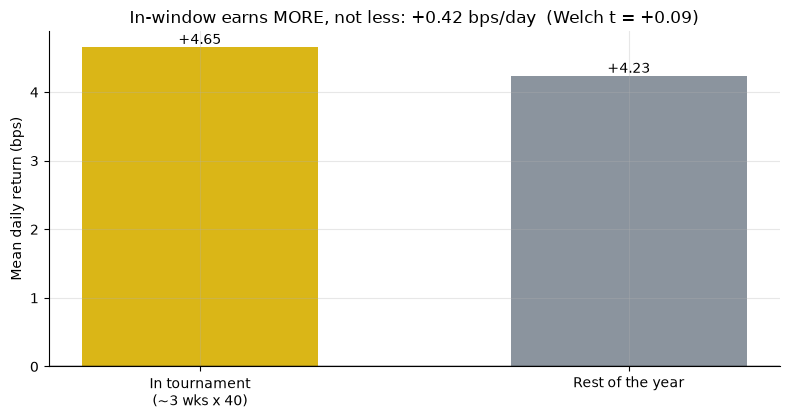

In-tournament: +4.65 bps/day  |  Outside: +4.23 bps/day
Difference: +0.42 bps/day -- the WRONG sign for a distraction drag.


In [3]:
if HAVE_REAL:
    rt = st.tournament_return_test(ret, mask)
    in_bps, out_bps, diff = rt['in_mean_bps'], rt['out_mean_bps'], rt['diff_bps']
    welch = rt['welch_t']
else:
    in_bps, out_bps = R['in_mean_bps'], R['out_mean_bps']
    diff, welch = R['diff_bps'], R['welch_t']

fig, ax = plt.subplots(figsize=(8.0, 4.3))
bars = ax.bar(['In tournament\n(~3 wks x 40)', 'Rest of the year'],
              [in_bps, out_bps], color=[AMBER, GREY], width=0.55)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Mean daily return (bps)')
ax.set_title(f'In-window earns MORE, not less: {diff:+.2f} bps/day  (Welch t = {welch:+.2f})')
for b, v in zip(bars, [in_bps, out_bps]):
    ax.annotate(f'{v:+.2f}', (b.get_x()+b.get_width()/2, v),
                ha='center', va='bottom')
plt.tight_layout(); plt.show()
print(f'In-tournament: {in_bps:+.2f} bps/day  |  Outside: {out_bps:+.2f} bps/day')
print(f'Difference: {diff:+.2f} bps/day -- the WRONG sign for a distraction drag.')

The distraction story predicts in-window returns *below* the rest of the tape. Instead they're a hair **higher** (+0.42 bps/day), and the difference (Welch t = +0.09) is statistically indistinguishable from zero. The folklore is not just unsupported -- the only non-zero direction it shows is backwards.

**Is the market more chaotic during the bracket?**

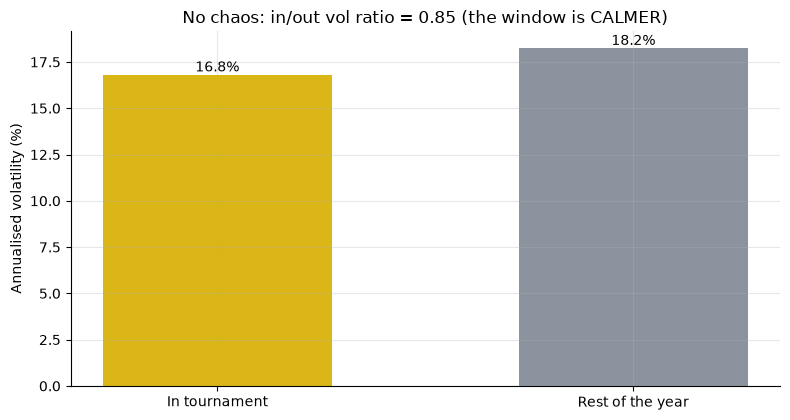

In-window vol 16.8% vs outside 18.2% -- ratio 0.85
The madness-is-chaos corollary fails too: the window is slightly calmer.


In [4]:
if HAVE_REAL:
    vt = st.tournament_vol_test(ret, mask)
    in_vol, out_vol, ratio = vt['in_vol_ann']*100, vt['out_vol_ann']*100, vt['vol_ratio']
else:
    in_vol, out_vol, ratio = R['in_vol_pct'], R['out_vol_pct'], R['vol_ratio']

fig, ax = plt.subplots(figsize=(8.0, 4.3))
bars = ax.bar(['In tournament', 'Rest of the year'], [in_vol, out_vol],
              color=[AMBER, GREY], width=0.55)
ax.set_ylabel('Annualised volatility (%)')
ax.set_title(f'No chaos: in/out vol ratio = {ratio:.2f} (the window is CALMER)')
for b, v in zip(bars, [in_vol, out_vol]):
    ax.annotate(f'{v:.1f}%', (b.get_x()+b.get_width()/2, v),
                ha='center', va='bottom')
plt.tight_layout(); plt.show()
print(f'In-window vol {in_vol:.1f}% vs outside {out_vol:.1f}% -- ratio {ratio:.2f}')
print('The madness-is-chaos corollary fails too: the window is slightly calmer.')

The 'madness = chaos' corollary fails as well. In-window volatility is **16.8%** vs **18.2%** outside -- a ratio of 0.85. If anything, the bracket weeks are a touch calmer than the rest of the year.

## 5 - The verdict

- **Signal -- None.** In-window mean **+0.42 bps/day** (Welch t = **+0.09**) -- the wrong sign and indistinguishable from zero. Volatility ratio **0.85** (calmer, not chaotic). A random window of the same size beats it **53%** of the time. Returns are price-only on a single broad index, so survivorship isn't a factor -- there's simply nothing here.
- **Tradability -- Mirage.** Holding cash during the bracket ties buy-and-hold (+0.02pp/yr after a one-day lag and costs). No vehicle, no edge.
- **Busted.** The productivity-loss headlines are real; the market impact is not. The marginal price-setter in S&P 500 futures is not filling out a bracket.

## 6 - Could you actually trade it?

The most generous trade: hold cash during the tournament window, stay long the index otherwise (entering/exiting one day late, paying a small cost each switch).

In [5]:
if HAVE_REAL:
    av = st.tournament_avoidance(ret, mask, lag=1, cost_bps=1.0)
    bah, net, exc, t = (av['bah_cagr'], av['strat_net_cagr'],
                        av['excess_net_cagr'], av['excess_net_hac_t'])
else:
    bah, net = R['bah_cagr_pct']/100, R['strat_net_cagr_pct']/100
    exc, t = R['excess_net_pp']/100, R['excess_net_t']

print(f'Buy & hold (price-only):     {bah:.2%}/yr')
print(f'Avoidance, net of costs:     {net:.2%}/yr')
print(f'Edge from sitting out March: {exc*100:+.2f} pp/yr  (HAC t = {t:+.2f})')
print()
print('A statistical tie -- and the index drifts UP, so stepping out of ~5% of')
print('days that were marginally positive on average gives back what it saves.')

Buy & hold (price-only):     9.48%/yr
Avoidance, net of costs:     9.50%/yr
Edge from sitting out March: +0.02 pp/yr  (HAC t = -0.10)

A statistical tie -- and the index drifts UP, so stepping out of ~5% of
days that were marginally positive on average gives back what it saves.


The avoidance strategy is a dead heat with buy-and-hold. Because the index drifts up and the in-window days were marginally *positive*, sitting them out forgoes about as much as it avoids -- and the commissions finish the job. There is no trade in the bracket.

## 7 - Going further

- **The positive control:** the companion notebook plants a downward tournament drag into a synthetic tape and shows the same machinery detects it once it's big enough. The real tape has nothing like it.
- **Sister folklore:** the [Super-Bowl Indicator (Study 158)](../../158-super-bowl/) and [Mercury-Retrograde (Study 164)](../../164-mercury-retrograde/) are the same in-window-vs-out discipline applied to other omens.

*Think the bracket really moves the tape? Fork this, pick your own window definition, and show an in/out gap that clears |t| = 2 on the real ^GSPC tape. That's the bar -- and the data points the other way.*